---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Robert Underwood
    orcid: 0000-0002-1464-729X
    affiliations:
      - name: Argonne National Laboratory
        ror: 05gvnxz63
      - name: University of Chicago
        ror: 024mw5h28
    github: robertu94
---

# LibPressio

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![documentation-badge]][documentation-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v1.0.7+-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[documentation-badge]: https://img.shields.io/badge/documentation-grey?style=for-the-badge&logo=readthedocs&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[version-url]: https://github.com/juntyr/libpressio/tree/605fad30d43fd0787e35bf819642bd6f535772fd
[citation-url]: https://doi.org/10.1109/drbsd754563.2021.00005
[source-url]: https://github.com/robertu94/libpressio
[documentation-url]: https://robertu94.github.io/libpressio/
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/g-pressio.pdf

LibPressio [^libpressio] is a compression framework that simplifies compressor configuration and targets deployment in high-performance computing. LibPressio provides common interfaces for several types of plugins, including data I/O, data domains, compressors, metrics, and parallelisation. LibPressio also provides convenient global configuration options e.g. for bounding the pointwise absolute error, such that users do not need to learn the various compressor-specific configuration formats.

The native installation of LibPressio can be configured to include wrappers for over 50 scientific compressors and metacompressors, including ZFP, SZ3, and SPERR. The initial version provided in `numcodecs-wasm-pressio` does not include most compressors supported by the native version. The auto-tuning meta-compressor, OptZConfig [^optzconfig], is also not yet included.

This product includes software produced by UChicago Argonne, LLC under Contract No. DE-AC02-06CH11357 with the Department of Energy.

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. In *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

[^optzconfig]: Underwood, R., Calhoun, J. C., Di, S., Apon, A., & Cappello, F. (2022). OptZConfig: Efficient parallel optimization of lossy compression configuration. *IEEE Transactions on Parallel and Distributed Systems*, 33(12), 3505–3519. Available from: [doi:10.1109/tpds.2022.3154096](https://doi.org/10.1109/tpds.2022.3154096).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

[pyodide]: Loading fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loaded fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 90 new dynamic libraries (93 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Importing the `Pressio` meta-compressor

In [5]:
from numcodecs_wasm_pressio import Pressio

[pyodide]: Loading Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_pressio, wrapt
[pyodide]: Loaded Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_pressio, wrapt
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Memory usage has grown to 268.7MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 12 new dynamic libraries (112 total for this notebook)


In [6]:
?Pressio

Init signature:
Pressio(
    compressor_id,
    _version='1.0.0',
    compressor_config={},
    early_config={},
    metric_results={},
    name=None,
)
Docstring:     
Pressio codec which applies the identity function, i.e. passes through the
input unchanged during encoding and decoding.

Parameters
----------
compressor_id : ...
    The id of the compressor
_version : ..., optional, default = "1.0.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
compressor_config : ..., optional, default = {}
    Configuration for the compressor
early_config : ..., optional, default = {}
    Configuration for the structure of the compressor
metric_results : ..., optional, default = {}
    Results of the compressor metrics (output-only)
name : ..., optional, default = None
    Optional name for the compressor when used in hierarchical mode
File:           /lib/python3.14/site-packages/numcodecs_wasm_pressio/__init__.py
Type:           ABCMeta
Subclasses:     


### Supported Compressors

The complete list of supported compressors that were enabled during the build of LibPressio can be inspected by providing an invalid compressor id:

In [7]:
try:
    Pressio(compressor_id="???")
except Exception as err:  # noqa: BLE001
    print(err)


 1 | {"compressor_id":"???"}
   |                        ^ invalid compressor id ???, choose one of: `binning`, `bzip2`, `cast`, `chunking`, `delta_encoding`, `lambda_fn`, `linear_quantizer`, `log_transform`, `many_dependent`, `many_independent`, `mask_binning`, `mask_interpolation`, `noop`, `numcodecs.rs`, `opt`, `pipeline`, `pressio`, `pw_rel`, `remove_background`, `repeat`, `resize`, `roibin`, `sample`, `switch`, `threshold_small`, `transpose` at line 1 column 23



## Bounding the pointwise absolute error

Pressio can bound the absolute error for a supporting compressor, e.g. linear quantisation, using:

In [8]:
eb_abs = 1.0

Pressio(
    compressor_id="linear_quantizer",
    early_config={"linear_quantizer:compressor": "bzip2"},
    compressor_config={"pressio:abs": eb_abs},
)

Pressio(compressor_id='linear_quantizer', early_config={'linear_quantizer:compressor': 'bzip2'}, compressor_config={'bzip2:block_size_100k': 9, 'bzip2:metric': 'noop', 'bzip2:small': 0, 'bzip2:verbosity': 0, 'bzip2:work_factor': 30, 'linear_quantizer:auto_step': 0, 'linear_quantizer:compressor': 'bzip2', 'linear_quantizer:metric': 'noop', 'linear_quantizer:step': 1.0, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'pressio:abs': 1.0, 'pressio:lossless': 9, 'pressio:metric': 'noop'}, _version='1.0.0')

## Bounding the range-relative error

Pressio can bound the range-relative error for a supporting compressor using:

```python
eb_range_rel = 0.01

Pressio(compressor_id="...", compressor_config={"pressio:rel": eb_range_rel})
```

## Bounding the pointwise relative error

Pressio can bound the relative error for a supporting compressor using:

```python
eb_rel = 0.01

Pressio(compressor_id="...", compressor_config={"pressio:pw_rel": eb_rel})
```

Alternatively, the `pw_rel` meta-compressor plugin can be used to transform the relative error bound into an absolute error bound for a compressor that only supports absolute error bounds using:

In [9]:
eb_rel = 0.01

Pressio(
    compressor_id="pw_rel",
    early_config={
        "pw_rel:abs_comp": "linear_quantizer",
        "linear_quantizer:compressor": "bzip2",
        "pw_rel:sign_comp": "bzip2",
    },
    compressor_config={"pressio:pw_rel": eb_rel},
)

Pressio(compressor_id='pw_rel', early_config={'linear_quantizer:compressor': 'bzip2', 'pw_rel:abs_comp': 'linear_quantizer', 'pw_rel:sign_comp': 'bzip2'}, compressor_config={'bzip2:block_size_100k': 9, 'bzip2:metric': 'noop', 'bzip2:small': 0, 'bzip2:verbosity': 0, 'bzip2:work_factor': 30, 'linear_quantizer:auto_step': 0, 'linear_quantizer:compressor': 'bzip2', 'linear_quantizer:metric': 'noop', 'linear_quantizer:step': 0.0, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'pressio:abs': 0.0, 'pressio:lossless': 9, 'pressio:metric': 'noop', 'pressio:pw_rel': 0.009999999776482582, 'pw_rel:abs_comp': 'linear_quantizer', 'pw_rel:metric': 'noop', 'pw_rel:sign_comp': 'bzip2'}, _version='1.0.0')

## Preserving Missing Values

LibPressio preserves NaN values if the underlying compressor preserves NaN values. If the underlying compressor raises an exception when the data includes NaN values, the `mask_interpolation` meta-compressor can be used to replace the NaN values with a fill value using:

In [10]:
da = xr.DataArray(data=np.array([1.0, np.nan, 2.0]))  # for example

Pressio(
    compressor_id="mask_interpolation",
    early_config={
        "mask_interpolation:compressor": "...",
    },
    compressor_config={
        "mask_interpolation:mask": np.isnan(da.values).tolist(),
        "mask_interpolation:mask_mode": "fill",
        "mask_interpolation:fill": np.nanmean(da),
    },
)

Pressio(compressor_id='mask_interpolation', early_config={'mask_interpolation:compressor': '...'}, compressor_config={'mask_interpolation:compressor': 'noop', 'mask_interpolation:fill': 1.5, 'mask_interpolation:mask': [False, True, False], 'mask_interpolation:mask_mode': 'fill', 'mask_interpolation:metric': 'noop', 'mask_interpolation:nthreads': 1, 'metrics:copy_compressor_results': 1, 'metrics:errors_fatal': 1, 'noop:metric': 'noop', 'pressio:metric': 'noop', 'pressio:nthreads': 1}, _version='1.0.0')

[pyodide]: Loaded 27 new dynamic libraries (139 total for this notebook)


## Example

In [11]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="h5netcdf",
    decode_timedelta=True,
)
da = ds["2t"]

[pyodide]: Loading ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loading WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loaded WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loading donfig, google-crc32c, zarr
[pyodide]: Loaded donfig, google-crc32c, zarr
[pyodide]: Loading arraypartition, cfapyx
[pyodide]: Loaded arraypartition, cfapyx


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, pooch
[pyodide]: Loaded MetPy, pooch
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Memory usage has grown to 322.4MiB (from 268.7MiB) for this notebook
[pyodide]: Loaded 89 new dynamic libraries (228 total for this notebook)


In [12]:
eb_rel = 0.01  # 1%

codec = Pressio(
    compressor_id="pw_rel",
    early_config={
        "pw_rel:abs_comp": "linear_quantizer",
        "linear_quantizer:compressor": "bzip2",
        "pw_rel:sign_comp": "bzip2",
        "pressio:metric": "composite",
    },
    compressor_config={
        "pressio:pw_rel": eb_rel,
        # record some metrics about compression
        "composite:plugins": ["input_stats", "size", "max_error"],
    },
)

In [13]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc, out=np.empty(da.shape, dtype=da.dtype)))

[pyodide]: Memory usage has grown to 464.4MiB (from 322.4MiB) for this notebook


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


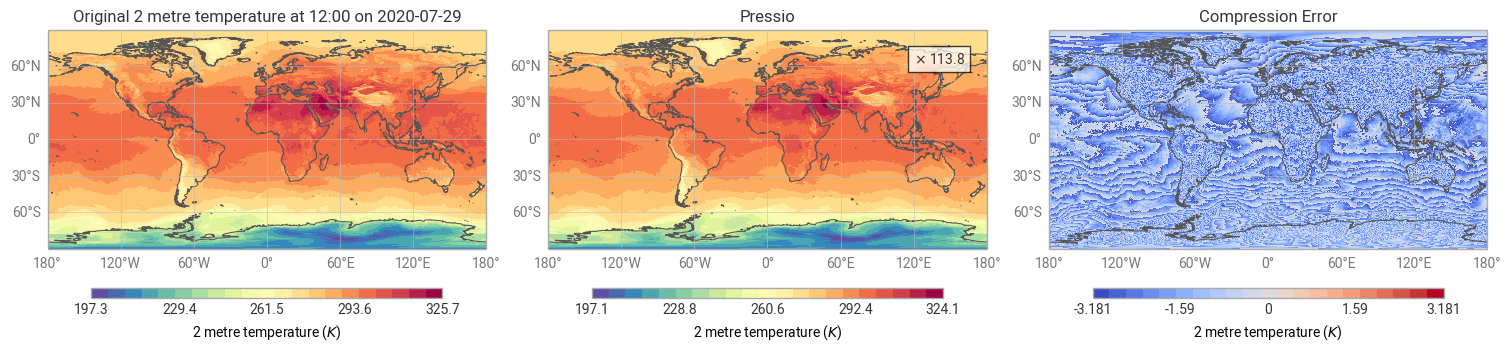

[pyodide]: Memory usage has grown to 987.8MiB (from 464.4MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (230 total for this notebook)


In [14]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="Pressio", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()

In [15]:
codec.get_config().get("metric_results", {})

{'input_stat:compress_input_dims': [[4], [721], [1440]],
 'input_stat:compress_input_types': [0],
 'input_stat:compress_output_dims': [[291958]],
 'input_stat:compress_output_types': [10],
 'input_stat:decompress_input_dims': [[291958]],
 'input_stat:decompress_input_types': [2],
 'input_stat:decompress_output_dims': [[4], [721], [1440]],
 'input_stat:decompress_output_types': [0],
 'max_error:max_error': 3.180715545728674,
 'max_error:max_error_index': 329940,
 'size:bit_rate': 0.5624094621667437,
 'size:compressed_size': 291958,
 'size:compression_ratio': 113.79609395872008,
 'size:decompressed_size': 33223680,
 'size:uncompressed_size': 33223680}